<a href="https://colab.research.google.com/github/Yuliia-Safonova/DTA-2026/blob/main/homework/practice_stat_tests_17_06_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Статистичні тести: практикум

**Тривалість:** ~4 години · бібліотека `scipy.stats`

---

Цей практикум закріплює лекцію про p-значення та статистичну значущість. Він влаштований так:

- 🟦 **Теорія** — короткий блок перед кожним тестом: *коли* його обирати, *чому*, *як читати результат*.
- ✏️ **Завдання (код)** — ви пишете код, що проводить тест.
- 💬 **Інтерпретація** — ви **своїми словами** пояснюєте, що означає результат. Це найважливіша частина! Аналітик, який уміє порахувати p-значення, але не вміє його пояснити — це лише калькулятор.

## Як працювати
1. Читайте теоретичний блок.
2. Виконуйте завдання на код (Shift+Enter).
3. На кожне питання інтерпретації відповідайте **повним реченням людською мовою** — так, ніби пояснюєте керівнику без технічної освіти.

## Загальне правило
- `p < 0.05` → статистично значущо → відхиляємо H₀
- `p ≥ 0.05` → не значущо → не відхиляємо H₀

> 💡 Тримайте поруч шпаргалку вибору тесту з лекції. Половина завдань — про те, щоб **обрати правильний тест**.

---

## Підготовка

Запустіть цю клітинку. Ми працюємо з двома наборами даних:
- **`shop_customers.csv`** — 500 клієнтів інтернет-магазину
- **`ab_test.csv`** — результати A/B-тесту (8000 сесій)


In [71]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

df = pd.read_csv("shop_customers.csv")
ab = pd.read_csv("ab_test.csv")

print("Клієнти:", df.shape)
print("A/B тест:", ab.shape)
df.head()

Клієнти: (500, 11)
A/B тест: (8000, 3)


,customer_id,gender,age,country,channel,device,spend,session_min,sat_before,sat_after,purchased
0,1001,Ч,23,Німеччина,Реклама,Desktop,997.11,22.2,6,7,Так
1,1002,Ч,38,Україна,Органіка,Desktop,510.09,19.8,5,8,Ні
2,1003,Ч,20,Україна,Соцмережі,Desktop,789.71,21.0,7,8,Ні
3,1004,Ч,40,Німеччина,Соцмережі,Desktop,1041.02,17.4,8,9,Ні
4,1005,Ч,18,Україна,Реклама,Desktop,944.34,23.5,6,7,Ні


### Опис даних `shop_customers.csv`

| Стовпець | Опис | Тип |
|---|---|---|
| `customer_id` | ID клієнта | — |
| `gender` | Стать (Ч/Ж) | категоріальний |
| `age` | Вік | числовий |
| `country` | Країна | категоріальний |
| `channel` | Канал залучення (Органіка/Реклама/Соцмережі) | категоріальний |
| `device` | Пристрій (Mobile/Desktop) | категоріальний |
| `spend` | Витрати клієнта, грн | числовий |
| `session_min` | Час на сайті, хв | числовий |
| `sat_before` | Задоволеність ДО редизайну (1-10) | числовий |
| `sat_after` | Задоволеність ПІСЛЯ редизайну (1-10) | числовий |
| `purchased` | Чи зробив покупку (Так/Ні) | категоріальний |

Спочатку завжди корисно роздивитись дані.

#### ✏️ Завдання 1 (код)

Виведіть основну статистику по числових стовпцях (підказка: метод `.describe()`).

In [72]:
# Завдання 1:
df.describe()

,customer_id,age,spend,session_min,sat_before,sat_after
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,1250.500000,34.646000,845.016340,20.739400,6.536000,7.138000
std,144.481833,10.961615,333.460589,10.532489,1.523597,1.826919
min,1001.000000,18.000000,50.000000,1.000000,2.000000,1.000000
25%,1125.750000,26.000000,612.627500,13.100000,6.000000,6.000000
50%,1250.500000,34.000000,834.750000,20.850000,7.000000,7.000000
75%,1375.250000,41.250000,1070.395000,27.400000,8.000000,9.000000
max,1500.000000,69.000000,1952.020000,52.200000,10.000000,10.000000


#### ✏️ Завдання 2 (код)

Скільки клієнтів у кожному каналі залучення? (підказка: `.value_counts()` на стовпці `channel`)

In [73]:
# Завдання 2:
channel_counts = df['channel'].value_counts()
display(channel_counts)

,count
channel,
Органіка,174
Соцмережі,167
Реклама,159


---
# Розділ 1. Одновибірковий t-тест

## 🟦 Теорія: коли і чому

**Коли обирати:** коли у вас є **одна** група числових даних, і ви хочете порівняти її **середнє** з якимось **фіксованим, наперед відомим числом** (ціль, норматив, заявлене значення).

**Чому саме він:** ми перевіряємо, чи відхилення нашого середнього від цільового числа реальне, чи це випадковість вибірки.

**Гіпотези:**
- H₀: середнє = цільове число
- H₁: середнє ≠ цільове число

**Функція:** `stats.ttest_1samp(дані, цільове_число)`

**Як читати:** дивимось на p-значення. Якщо `p < 0.05` — середнє значущо відрізняється від цільового.

**Приклад із життя:** виробник заявляє, що пакет чипсів важить 100 г. Ви зважили 50 пакетів. Чи справді середня вага = 100 г, чи вас обманюють?

**Сценарій:** маркетолог стверджує, що середній час на сайті становить 20 хвилин. Перевіримо це.

#### ✏️ Завдання 3 (код)

Порахуйте фактичний середній `session_min`. Потім проведіть одновибірковий t-тест, щоб перевірити, чи відрізняється він від 20. Виведіть t-статистику та p-значення.

In [74]:
# Завдання 3:
mean_session = df['session_min'].mean()
print(f"Фактичний середній перегляд: {mean_session:.1f} хв\n")

t_stat, p_value = stats.ttest_1samp(df['session_min'], 20)

print(f"t-статистика: {t_stat:.3f}")
print(f"p-значення:   {p_value:.4f}")

if p_value < 0.05:
    print("\n✅ p < 0.05 → TOO MUCH: середнє ВІДРІЗНЯЄТЬСЯ від 20 хв")
else:
    print("\n❌ p ≥ 0.05 → NOT too much: немає підстав казати, що середній час перегляду ≠ 20 хв")

Фактичний середній перегляд: 20.7 хв

t-статистика: 1.570
p-значення:   0.1171

❌ p ≥ 0.05 → NOT too much: немає підстав казати, що середній час перегляду ≠ 20 хв


#### 💬 Інтерпретація 1

Чи відрізняється середній час на сайті від заявлених 20 хвилин? Сформулюйте висновок для маркетолога: він мав рацію чи ні? Чому ви так вважаєте (спирайтесь на p-значення)?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Середній час перебування на сайті становить 20.7 хвилини, що трохи більше за заявлені 20 хвилин.

Однак результат t-тесту показав p-значення = 0.1171, що більше за рівень значущості 0.05.

Тому ми не відхиляємо нульову гіпотезу (H₀) і не маємо достатніх статистичних доказів того, що середній час на сайті відрізняється від 20 хвилин.

**Другий сценарій:** керівник вважає, що середні витрати клієнта = 850 грн.

#### ✏️ Завдання 4 (код)

Перевірте за допомогою одновибіркового t-тесту, чи середні витрати (`spend`) відрізняються від 850 грн.

In [75]:
# Завдання 4:
mean_spend = df['spend'].mean()
print(f"Фактичні середні витрати: {mean_spend:.1f} грн\n")

t_stat, p_value = stats.ttest_1samp(df['spend'], 850)

print(f"t-статистика: {t_stat:.3f}")
print(f"p-значення:   {p_value:.4f}")

if p_value < 0.05:
    print("\n✅ p < 0.05 → витрати СТАТИСТИЧНО ВІДРІЗНЯЮТЬСЯ від 850 грн")
else:
    print("\n❌ p ≥ 0.05 → значущої різниці від 850 грн НЕ ВИЯВЛЕНО")

Фактичні середні витрати: 845.0 грн

t-статистика: -0.334
p-значення:   0.7384

❌ p ≥ 0.05 → значущої різниці від 850 грн НЕ ВИЯВЛЕНО


#### 💬 Інтерпретація 2

Що показав тест? Чи можна сказати, що середні витрати дорівнюють 850 грн? Поясніть, чому тут ми НЕ відхиляємо нульову гіпотезу (зверніть увагу на формулювання: чи це означає, що середнє точно дорівнює 850?).

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Фактичні середні витрати клієнтів становлять 845 грн, що дуже близько до перевірюваного значення 850 грн.

Результат t-тесту показав p-значення = 0.7384, що значно більше за рівень значущості 0.05. Тому ми не відхиляємо нульову гіпотезу (H₀).  

Ми не можемо стверджувати, що середні витрати точно дорівнюють 850 грн. Ми можемо лише сказати, що за наявними даними різниця між середнім значенням (845 грн) і 850 грн настільки мала, що її можна пояснити випадковими коливаннями вибірки.

---
# Розділ 2. Двовибірковий t-тест (незалежні групи)

## 🟦 Теорія: коли і чому

**Коли обирати:** коли ви порівнюєте **середні двох РІЗНИХ, незалежних груп** числових даних.

**Чому саме він:** хочемо дізнатись, чи різниця між групами реальна, чи могла виникнути випадково.

**Ключова умова — групи НЕЗАЛЕЖНІ:** різні люди в кожній групі (на відміну від парного тесту, де ті самі люди двічі).

**Гіпотези:**
- H₀: середнє групи 1 = середнє групи 2
- H₁: вони відрізняються

**Функція:** `stats.ttest_ind(група1, група2)`

**Приклад із життя:** чи відрізняється середня зарплата у двох відділах? Чи витрачають більше клієнти з міста А порівняно з містом Б?

**Сценарій:** чи витрачають клієнти з мобільних більше, ніж з десктопу?

#### ✏️ Завдання 5 (код)

Розділіть `spend` на дві групи за `device` (Mobile та Desktop). Виведіть середнє кожної групи і проведіть двовибірковий t-тест.

In [76]:
# Завдання 5:
spend_mobile = df[df["device"] == "Mobile"]["spend"]
spend_desktop = df[df["device"] == "Desktop"]["spend"]

print(f"Mobile:  {spend_mobile.mean():.1f} грн")
print(f"Desktop: {spend_desktop.mean():.1f} грн")

t_stat, p_value = stats.ttest_ind(spend_mobile, spend_desktop)

print(f"\nt-статистика: {t_stat:.3f}")
print(f"p-значення:   {p_value:.4f}")

if p_value < 0.05:
    print("\n✅ p < 0.05 → середні витрати ЗНАЧУЩО відрізняються")
else:
    print("\n❌ p ≥ 0.05 → значущої різниці НЕ виявлено")

Mobile:  835.2 грн
Desktop: 861.2 грн

t-статистика: -0.844
p-значення:   0.3993

❌ p ≥ 0.05 → значущої різниці НЕ виявлено


#### 💬 Інтерпретація 3

Чи є значуща різниця у витратах між Mobile та Desktop? Якби ви були аналітиком, чи порадили б компанії інвестувати в мобільну версію на основі цього результату?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Середні витрати користувачів Desktop (861.2 грн) вищі за витрати користувачів Mobile (835.2 грн). Різниця становить приблизно 26 грн.

Однак результат двовибіркового t-тесту показав p-значення = 0.3993, що значно більше за рівень значущості 0.05.

Тому ми не відхиляємо нульову гіпотезу (H₀) і не маємо достатніх статистичних доказів того, що середні витрати користувачів Mobile та Desktop дійсно відрізняються.

Висновок: на основі цього тесту не можна стверджувати, що один тип пристрою приносить більше доходу, ніж інший.  


---

Висновок як аналітика: на основі цього тесту не можна стверджувати, що один тип пристрою приносить більше доходу, ніж інший. Різниця у 26 грн може бути наслідком випадкових коливань у вибірці. Тому я б не рекомендує інвестувати в мобільну версію лише на підставі цього результату.  
Для такого рішення потрібні додаткові дані та метрики, наприклад:
* конверсія в покупку для Mobile та Desktop
* кількість користувачів кожного типу пристрою
* середній чек
* час на сайті

Отже, поточний аналіз показує, що статистично значущої різниці у витратах між Mobile та Desktop не виявлено, тому даних недостатньо для обгрунтування інвестицій саме в мобільну версію.

**Сценарій:** чи різниться час на сайті залежно від статі?

#### ✏️ Завдання 6 (код)

Порівняйте `session_min` між чоловіками та жінками за допомогою двовибіркового t-тесту.

In [77]:
# Завдання 6:
session_m = df[df["gender"] == "Ч"]["session_min"]
session_f = df[df["gender"] == "Ж"]["session_min"]

print(f"Чоловіки: {session_m.mean():.1f} хв")
print(f"Жінки:    {session_f.mean():.1f} хв")

t_stat, p_value = stats.ttest_ind(session_m, session_f)

print(f"\nt-статистика: {t_stat:.4f}")
print(f"p-значення:   {p_value:.4f}")

if p_value < 0.05:
    print("\n✅ p < 0.05 → відхиляємо H₀: середній час на сайті залежить від статі")
else:
    print("\n❌ p ≥ 0.05 → не відхиляємо H₀: статистично значущої різниці не виявлено")

Чоловіки: 20.8 хв
Жінки:    20.6 хв

t-статистика: 0.2324
p-значення:   0.8163

❌ p ≥ 0.05 → не відхиляємо H₀: статистично значущої різниці не виявлено


#### 💬 Інтерпретація 4

Сформулюйте висновок. Якщо різниця не значуща — що це означає на практиці для команди маркетингу?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Середній час перебування на сайті у чоловіків становить 20.8 хв, а у жінок — 20.6 хв. Різниця між групами дуже мала і складає лише 0.2 хвилини.

Результат двовибіркового t-тесту показав p-значення = 0.8163, що значно більше за рівень значущості 0.05.

Тому ми не відхиляємо нульову гіпотезу (H₀) і робимо висновок, що статистично значущої різниці в середньому часі перебування на сайті між чоловіками та жінками не виявлено.

Тому, немає підстав розділяти користувачів за статтю лише через показник часу перебування на сайті. Чоловіки та жінки взаємодіють із сайтом приблизно однаково довго.  

---
**Практичний висновок для маркетингу**

Для команди маркетингу це означає, що немає підстав розділяти користувачів за статтю лише через показник часу перебування на сайті. Чоловіки та жінки взаємодіють із сайтом приблизно однаково довго.

Тому на основі цього результату не варто створювати окремі маркетингові кампанії або змінювати дизайн сайту спеціально для чоловіків чи жінок з метою збільшення часу перебування.

---
# Розділ 3. Парний t-тест

## 🟦 Теорія: коли і чому

**Коли обирати:** коли ви маєте **два виміри в ОДНИХ І ТИХ САМИХ обʼєктів** — типово «до і після» якоїсь зміни.

**Чому саме він (а не звичайний t-тест):** виміри пов'язані (той самий клієнт до і після). Парний тест враховує цей зв'язок і тому **потужніший** — він краще виявляє реальні зміни.

**Гіпотези:**
- H₀: середня різниця (після − до) = 0 (зміни немає)
- H₁: середня різниця ≠ 0 (зміна є)

**Функція:** `stats.ttest_rel(до, після)`

**Приклад із життя:** вага пацієнтів до і після дієти. Продуктивність працівників до і після тренінгу. Бали студентів до і після курсу.

> ⚠️ Головна підказка для вибору: якщо ви бачите слова «до/після», «був/став», «той самий обʼєкт двічі» — це парний тест.

**Сценарій:** компанія зробила редизайн сайту і виміряла задоволеність тих самих клієнтів до (`sat_before`) і після (`sat_after`).

#### ✏️ Завдання 7 (код)

Проведіть парний t-тест, щоб перевірити, чи змінилася задоволеність клієнтів після редизайну. Виведіть середні значення до і після, а також p-значення.

In [78]:
# Завдання 7:
print(f"Середня задоволеність ДО:    {df['sat_before'].mean():.2f}")
print(f"Середня задоволеність ПІСЛЯ: {df['sat_after'].mean():.2f}")

t_stat, p_value = stats.ttest_rel(df["sat_before"], df["sat_after"])

print(f"\nt-статистика: {t_stat:.3f}")
print(f"p-значення:   {p_value:.2e}")

if p_value < 0.05:
    print("\n✅ p < 0.05 → задоволеність ПІСЛЯ редизайну значущо змінилася")
else:
    print("\n❌ p ≥ 0.05 → значущої зміни задоволеності не виявлено")

Середня задоволеність ДО:    6.54
Середня задоволеність ПІСЛЯ: 7.14

t-статистика: -11.303
p-значення:   1.57e-26

✅ p < 0.05 → задоволеність ПІСЛЯ редизайну значущо змінилася


#### 💬 Інтерпретація 5

Чи спрацював редизайн? Поясніть, чому тут доречний саме ПАРНИЙ тест, а не звичайний двовибірковий. Що було б не так, якби ми використали `ttest_ind`?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Середня задоволеність клієнтів до редизайну становила 6.54, а після редизайну — 7.14. Тобто задоволеність зросла приблизно на 0.6 бала.

Результат парного t-тесту показав p-значення < 0.05 (фактично майже 0), тому ми відхиляємо нульову гіпотезу (H₀).

Отже, редизайн сайту спрацював: після його впровадження рівень задоволеності клієнтів статистично значущо зріс.

**Чому тут потрібен саме парний t-тест?**

Парний t-тест використовується тоді, коли ми порівнюємо два вимірювання одних і тих самих об'єктів.

У нашому випадку:  

* sat_before — оцінка того самого клієнта до редизайну  
* sat_after — оцінка того самого клієнта після редизайну

Тобто кожному значенню в sat_before відповідає конкретне значення в sat_after. Ми аналізуємо не дві незалежні групи, а зміну для кожного клієнта окремо.

**Що було б не так із ttest_ind?**

Функція stats.ttest_ind() припускає, що дві вибірки є незалежними. Якби ми використали ttest_ind, тест поводився б так, ніби оцінки до редизайну та після редизайну належать різним людям. При цьому втратилася б інформація про те, як змінилася оцінка кожного конкретного клієнта.

Через це:  

* збільшується вплив індивідуальних відмінностей між клієнтами
* тест стає менш точним
* можна отримати неправильні висновки щодо ефекту редизайну

Отже, парний t-тест є правильним вибором, тому що ми порівнюємо показники одних і тих самих клієнтів до та після змін. Він безпосередньо оцінює ефект редизайну, а не відмінності між різними людьми.

---
# Розділ 4. ANOVA (дисперсійний аналіз)

## 🟦 Теорія: коли і чому

**Коли обирати:** коли ви порівнюєте середні **ТРЬОХ або більше груп** числових даних.

**Чому не кілька t-тестів:** якби ми порівнювали групи попарно багатьма t-тестами, ми б накопичили помилки I роду (згадайте проблему множинних порівнянь!). ANOVA перевіряє все одним тестом.

**Гіпотези:**
- H₀: середні ВСІХ груп однакові
- H₁: принаймні одна група відрізняється

**Функція:** `stats.f_oneway(група1, група2, група3, ...)`

**Важливе обмеження:** ANOVA каже, що різниця Є, але не каже, **між якими саме** групами. Для цього потрібні додаткові (post-hoc) тести.

**Приклад із життя:** чи відрізняється врожайність при трьох різних добривах? Чи різний середній дохід у чотирьох регіонах?

**Сценарій:** чи залежать витрати клієнта від каналу залучення (Органіка / Реклама / Соцмережі)?

#### ✏️ Завдання 8 (код)

Виведіть середні `spend` для кожного каналу. Потім проведіть ANOVA, щоб перевірити, чи є значуща різниця між каналами. (Підказка: створіть список груп через цикл або вручну, потім передайте їх у `f_oneway`.)

In [79]:
# Завдання 8:
for channel in df["channel"].unique():
    avg_spend = df[df["channel"] == channel]["spend"].mean()
    print(f"{channel}: {avg_spend:.1f} грн")

groups = [df[df["channel"] == ch]["spend"] for ch in df["channel"].unique()]

f_stat, p_value = stats.f_oneway(*groups)
# f_stat, p_value = stats.f_oneway(groups[0], groups[1], groups[2])

print(f"\nF-статистика: {f_stat:.4f}")
print(f"p-значення:   {p_value:.2e}")

if p_value < 0.05:
    print("\n✅ p < 0.05 → принаймні один канал значущо відрізняється")
else:
    print("\n❌ p ≥ 0.05 → значущої різниці між каналами не виявлено")

Реклама: 1057.9 грн
Органіка: 791.3 грн
Соцмережі: 698.4 грн

F-статистика: 63.5400
p-значення:   2.68e-25

✅ p < 0.05 → принаймні один канал значущо відрізняється


#### 💬 Інтерпретація 6

Чи відрізняються канали за витратами? Який канал виглядає найприбутковішим? Чому на основі лише ANOVA ми НЕ можемо точно сказати, що, наприклад, Реклама значущо краща за Органіку?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Середні витрати клієнтів суттєво відрізняються залежно від каналу залучення:  
* Реклама: 1057.9 грн
* Органіка: 791.3 грн
* Соцмережі: 698.4 грн

ANOVA показала p-значення < 0.05, тому ми відхиляємо нульову гіпотезу (H₀) і робимо висновок, що між каналами існує статистично значуща різниця у середніх витратах. На основі середніх значень найприбутковішим виглядає канал "Реклама", оскільки клієнти, залучені через рекламу, у середньому витрачають найбільше коштів.

Чому ANOVA не дає повної відповіді? ANOVA перевіряє лише загальну гіпотезу:
* Чи всі середні однакові?  

У нашому випадку тест відповів: ❌ Ні, не всі середні однакові.

Але він не показує, між якими саме групами є різниця. Можливо, різниця існує лише між двома каналами, а третій від них не відрізняється. ANOVA цього не уточнює.  

ANOVA довела, що канал залучення впливає на витрати клієнтів, але для точного визначення, які саме канали відрізняються один від одного, потрібен додатковий аналіз.

**Сценарій:** чи залежить час на сайті (`session_min`) від країни клієнта?

#### ✏️ Завдання 9 (код)

Проведіть ANOVA для `session_min` за трьома країнами (`country`).

In [80]:
# Завдання 9:
for country in df["country"].unique():
    avg_session = df[df["country"] == country]["session_min"].mean()
    print(f"{country}: {avg_session:.1f} хв")

groups = [df[df["country"] == country]["session_min"] for country in df["country"].unique()]

f_stat, p_value = stats.f_oneway(*groups)

print(f"\nF-статистика: {f_stat:.3f}")
print(f"p-значення:   {p_value:.4f}")

if p_value < 0.05:
    print("\n✅ p < 0.05 → принаймні одна країна значущо відрізняється")
else:
    print("\n❌ p ≥ 0.05 → значущої різниці між країнами не виявлено")

Німеччина: 21.3 хв
Україна: 20.3 хв
Польща: 21.2 хв

F-статистика: 0.493
p-значення:   0.6111

❌ p ≥ 0.05 → значущої різниці між країнами не виявлено


#### 💬 Інтерпретація 7

Що показав результат? Сформулюйте висновок про звʼязок країни і часу на сайті.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Середній час перебування на сайті за країнами є дуже схожим:  
* Німеччина: 21.3 хв
* Україна: 20.3 хв
* Польща: 21.2 хв

Результат ANOVA показав p-значення = 0.6111, що значно більше за рівень значущості 0.05. Тому ми не відхиляємо нульову гіпотезу (H₀) і робимо висновок, що статистично значущої різниці в середньому часі перебування на сайті між країнами не виявлено.

Що це означає на практиці? Хоча середні значення трохи відрізняються, ці відмінності є настільки малими, що їх можна пояснити випадковими коливаннями вибірки. Іншими словами, країна клієнта не демонструє помітного впливу на час перебування на сайті в цьому наборі даних.

Висновок для бізнесу: на основі цього аналізу немає підстав вважати, що користувачі з різних країн поводяться по-різному з точки зору часу перебування на сайті.

Тому компанії навряд чи варто: створювати окремі версії сайту для цих країн лише з метою збільшення часу перебування або будувати маркетингову стратегію навколо країни як ключового фактора залученості.

Отже, у даній вибірці зв'язок між країною клієнта та часом перебування на сайті не виявлено. Користувачі з Німеччини, Польщі та України проводять на сайті приблизно однакову кількість часу.

---
# Розділ 5. Хі-квадрат (χ²)

## 🟦 Теорія: коли і чому

**Коли обирати:** коли обидві змінні **категоріальні**, і ви хочете перевірити, чи є між ними **звʼязок**.

**Чому саме він:** t-тест і ANOVA працюють із числами (середніми). Коли даних немає що усереднювати (категорії на кшталт «купив/не купив», «місто», «колір»), використовують хі-квадрат на основі **частот**.

**Гіпотези:**
- H₀: змінні незалежні (звʼязку немає)
- H₁: змінні повʼязані

**Як проводити (два кроки):**
1. Побудувати таблицю спряженості: `pd.crosstab(змінна1, змінна2)`
2. Передати її у `stats.chi2_contingency(таблиця)` — повертає chi2, p, dof, expected

**Приклад із життя:** чи повʼязана стать із вибором категорії товару? Чи залежить рішення про покупку від кольору кнопки (це і є A/B-тест для конверсій!)?

**Сценарій:** чи повʼязаний канал залучення (`channel`) із фактом покупки (`purchased`)?

#### ✏️ Завдання 10 (код)

Побудуйте таблицю спряженості між `channel` та `purchased`, виведіть її, потім проведіть тест хі-квадрат.

In [81]:
# Завдання 10:
contingency = pd.crosstab(df["channel"], df["purchased"])

print("Таблиця спряженості:")
display(contingency)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print(f"\nχ²-статистика: {chi2:.3f}")
print(f"p-значення:    {p_value:.4f}")

if p_value < 0.05:
    print("\n✅ p < 0.05 → канал залучення ПОВ'ЯЗАНИЙ із фактом покупки")
else:
    print("\n❌ p ≥ 0.05 → статистично значущого зв'язку не виявлено")

Таблиця спряженості:


purchased,Ні,Так
channel,,
Органіка,116,58
Реклама,110,49
Соцмережі,107,60



χ²-статистика: 0.957
p-значення:    0.6198

❌ p ≥ 0.05 → статистично значущого зв'язку не виявлено


---
# Розділ 5. Хі-квадрат (χ²)

## 🟦 Теорія: коли і чому

**Коли обирати:** коли обидві змінні **категоріальні**, і ви хочете перевірити, чи є між ними **звʼязок**.

**Чому саме він:** t-тест і ANOVA працюють із числами (середніми). Коли даних немає що усереднювати (категорії на кшталт «купив/не купив», «місто», «колір»), використовують хі-квадрат на основі **частот**.

**Гіпотези:**
- H₀: змінні незалежні (звʼязку немає)
- H₁: змінні повʼязані

**Як проводити (два кроки):**
1. Побудувати таблицю спряженості: `pd.crosstab(змінна1, змінна2)`
2. Передати її у `stats.chi2_contingency(таблиця)` — повертає chi2, p, dof, expected

**Приклад із життя:** чи повʼязана стать із вибором категорії товару? Чи залежить рішення про покупку від кольору кнопки (це і є A/B-тест для конверсій!)?

#### 💬 Інтерпретація 8

Чи виявив тест звʼязок між каналом залучення та покупкою? Сформулюйте висновок. Якщо звʼязку не виявлено — що це означає для бізнесу (чи варто обирати канал, орієнтуючись на ймовірність покупки)? Якщо звʼязок є — подивіться на частки в таблиці спряженості й опишіть, який канал вигідніший.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Тест хі-квадрат показав p-значення = 0.6198, що більше за рівень значущості 0.05. Тому ми не відхиляємо нульову гіпотезу (H₀) і робимо висновок, що статистично значущого зв'язку між каналом залучення та фактом покупки не виявлено. Це означає, що в нашій вибірці ймовірність того, що клієнт здійснить покупку, є приблизно однаковою незалежно від того, через який канал він був залучений.

Якщо подивитися на таблицю спряженості, то частки покупок у різних каналах дійсно схожі:

* Органіка: 58 покупок із 174 клієнтів (≈ 33%)
* Реклама: 49 покупок із 159 клієнтів (≈ 31%)
* Соцмережі: 60 покупок із 167 клієнтів (≈ 36%)

Хоча між каналами є невеликі відмінності, тест показав, що вони можуть бути випадковими і не є статистично значущими.

Що це означає для бізнесу? На основі цих даних не варто обирати канал залучення лише за критерієм ймовірності покупки, оскільки суттєвої різниці між каналами не виявлено. Отже, у даній вибірці канал залучення не впливає на факт покупки. Усі три канали демонструють приблизно однакову конверсію в покупку, тому вибір каналу слід робити на основі інших бізнес-метрик.

**Сценарій:** чи повʼязана стать (`gender`) із вибором пристрою (`device`)?

#### ✏️ Завдання 11 (код)

Перевірте за допомогою хі-квадрат, чи є звʼязок між статтю та пристроєм.

In [82]:
# Завдання 11:
contingency = pd.crosstab(df["gender"], df["device"])

print("Таблиця спряженості:")
display(contingency)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print(f"\nχ²-статистика: {chi2:.3f}")
print(f"p-значення:    {p_value:.4f}")

if p_value < 0.05:
    print("\n✅ p < 0.05 → стать ПОВ'ЯЗАНА з вибором пристрою")
else:
    print("\n❌ p ≥ 0.05 → статистично значущого зв'язку не виявлено")

Таблиця спряженості:


device,Desktop,Mobile
gender,,
Ж,93,158
Ч,96,153



χ²-статистика: 0.065
p-значення:    0.7993

❌ p ≥ 0.05 → статистично значущого зв'язку не виявлено


#### 💬 Інтерпретація 9

Сформулюйте висновок. Чи можна за цими даними сказати, що чоловіки й жінки користуються різними пристроями?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Тест хі-квадрат показав p-значення = 0.7993, що значно більше за рівень значущості 0.05. Тому ми не відхиляємо нульову гіпотезу (H₀) і робимо висновок, що статистично значущого зв'язку між статтю та вибором пристрою не виявлено.

Якщо подивитися на таблицю спряженості, розподіл користувачів є майже однаковим.
Чоловіки та жінки користуються мобільними пристроями та комп'ютерами у дуже схожих пропорціях. Відмінності між групами настільки малі, що їх можна пояснити випадковими коливаннями вибірки.

На основі цих даних не можна стверджувати, що чоловіки й жінки віддають перевагу різним типам пристроїв.
Тому немає підстав:
* створювати окремі мобільні або десктопні стратегії залежно від статі
* оптимізувати сайт під різні пристрої окремо для чоловіків і жінок
* використовувати стать як фактор прогнозування вибору пристрою.

Отже, у даній вибірці стать не пов'язана з вибором пристрою. Чоловіки та жінки користуються Desktop і Mobile приблизно однаково часто.

---
# Розділ 6. Кореляція

## 🟦 Теорія: коли і чому

**Коли обирати:** коли обидві змінні **числові**, і ви хочете виміряти **силу та напрямок звʼязку** між ними.

**Що повертає:** коефіцієнт кореляції **r** (від −1 до +1) ТА p-значення.
- **r ≈ +1** — сильний прямий звʼязок (одне зростає → інше зростає)
- **r ≈ −1** — сильний зворотний звʼязок (одне зростає → інше спадає)
- **r ≈ 0** — звʼязку немає
- **p-значення** — чи є цей звʼязок статистично значущим

**Функція:** `stats.pearsonr(змінна1, змінна2)`

**Гіпотези:**
- H₀: кореляції немає (r = 0)
- H₁: кореляція є (r ≠ 0)

> ⚠️ **Найважливіше попередження:** кореляція ≠ причинність! Значуща кореляція каже, що звʼязок реальний, але НЕ каже, що одне СПРИЧИНЯЄ інше.

**Приклад із життя:** чи повʼязаний зріст із вагою? Чи більше реклами → більше продажів?

**Сценарій:** чи повʼязаний час на сайті (`session_min`) із витратами (`spend`)?

#### ✏️ Завдання 12 (код)

Порахуйте кореляцію Пірсона між `session_min` та `spend`. Виведіть коефіцієнт r та p-значення. Додатково: побудуйте діаграму розсіювання (scatter plot), щоб побачити звʼязок очима.

Коефіцієнт кореляції r: 0.732
p-значення:            4.05e-85

✅ p < 0.05 → зв'язок статистично значущий


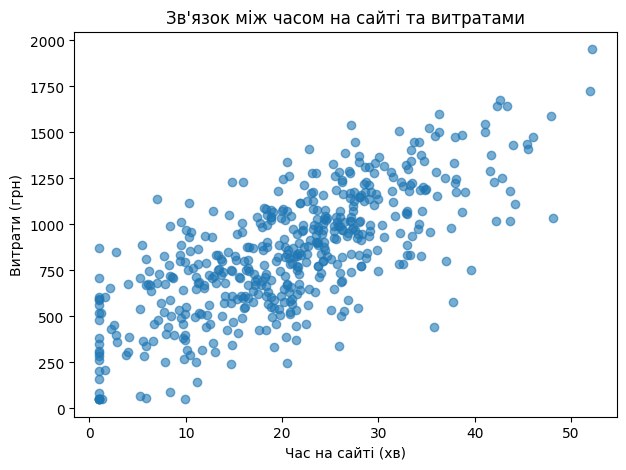

In [83]:
# Завдання 12:
r, p_value = stats.pearsonr(df["session_min"], df["spend"])

print(f"Коефіцієнт кореляції r: {r:.3f}")
print(f"p-значення:            {p_value:.2e}")

if p_value < 0.05:
    print("\n✅ p < 0.05 → зв'язок статистично значущий")
else:
    print("\n❌ p ≥ 0.05 → значущого зв'язку не виявлено")

plt.figure(figsize=(7, 5))

plt.scatter(df["session_min"], df["spend"], alpha=0.6)

plt.xlabel("Час на сайті (хв)")
plt.ylabel("Витрати (грн)")
plt.title("Зв'язок між часом на сайті та витратами")

plt.show()

#### 💬 Інтерпретація 10

Опишіть звʼязок: він прямий чи зворотний? Сильний чи слабкий? Значущий? І найголовніше: чи можна стверджувати, що довший час на сайті СПРИЧИНЯЄ більші витрати? Поясніть свою думку.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Коефіцієнт кореляції Пірсона становить r = 0.732, а p-значення < 0.05.

Отже, між часом перебування на сайті (session_min) та витратами клієнта (spend) існує статистично значущий сильний прямий зв'язок.
* Прямий зв'язок — тому що коефіцієнт кореляції додатний (r > 0).
* Сильний зв'язок — тому що значення r = 0.732 є досить близьким до 1.
* Статистично значущий зв'язок — тому що p-значення < 0.05.

Це означає, що клієнти, які проводять на сайті більше часу, зазвичай витрачають більше грошей.

Чи означає це, що довший час на сайті СПРИЧИНЯЄ більші витрати? Ні, кореляція не доводить причинно-наслідковий зв'язок. За результатами кореляційного аналізу ми можемо сказати лише те, що дві змінні пов'язані між собою. Але ми не можемо визначити, що саме є причиною, а що наслідком.

Можливі різні пояснення:
* довше перебування на сайті може сприяти більшим витратам
* клієнти, які планують великі покупки, можуть природно проводити більше часу на сайті
* на обидві змінні може впливати третій фактор (наприклад, зацікавленість товаром, тип клієнта або рекомендації).

Між часом на сайті та витратами існує сильний, прямий і статистично значущий зв'язок. Однак на основі лише кореляції не можна стверджувати, що довший час на сайті є причиною більших витрат.

**Сценарій:** чи повʼязаний вік клієнта (`age`) з його витратами (`spend`)?

#### ✏️ Завдання 13 (код)

Порахуйте кореляцію між `age` та `spend`.

In [84]:
# Завдання 13:
r, p_value = stats.pearsonr(df["age"], df["spend"])

print(f"Коефіцієнт кореляції r: {r:.3f}")
print(f"p-значення:            {p_value:.4f}")

if p_value < 0.05:
    print("\n✅ p < 0.05 → зв'язок статистично значущий")
else:
    print("\n❌ p ≥ 0.05 → значущого зв'язку не виявлено")

Коефіцієнт кореляції r: -0.042
p-значення:            0.3508

❌ p ≥ 0.05 → значущого зв'язку не виявлено


#### 💬 Інтерпретація 11

Що показала кореляція? Порівняйте цей результат із попереднім (час на сайті vs витрати). У якому випадку звʼязок сильніший і чому це важливо для бізнесу?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Коефіцієнт кореляції між віком клієнта та його витратами становить r = -0.042, а p-значення = 0.3508. Це означає, що між віком (age) та витратами (spend) спостерігається дуже слабкий від'ємний зв'язок, який практично дорівнює нулю.
Оскільки p-значення > 0.05, ми не маємо достатніх підстав стверджувати, що між віком і витратами існує статистично значущий зв'язок. Отже, у даній вибірці вік клієнта не пов'язаний із сумою його витрат.  

---

Порівняння з попереднім результатом

Для пари session_min - spend ми отримали:
* r = 0.732
* p < 0.05  

Це був сильний прямий і статистично значущий зв'язок.

Для пари age - spend ми отримали:
* r = -0.042
* p > 0.05

Це дуже слабкий і статистично незначущий зв'язок.

Таким чином, зв'язок між часом на сайті та витратами набагато сильніший, ніж між віком та витратами.

Чому це важливо для бізнесу? З точки зору бізнесу, корисно шукати фактори, які дійсно пов'язані з витратами клієнтів. У нашому аналізі: вік клієнта майже нічого не говорить про його майбутні витрати, а ось час перебування на сайті, навпаки, тісно пов'язаний із витратами.

Тому компанії доцільніше:
* аналізувати поведінку користувачів на сайті
* покращувати залученість та взаємодію з контентом
* досліджувати фактори, які збільшують час перебування на сайті

Водночас сегментація клієнтів лише за віком навряд чи допоможе суттєво підвищити продажі, оскільки в даних не спостерігається зв'язку між віком та витратами. Отже, час на сайті є набагато кориснішим показником для прогнозування витрат клієнта, ніж його вік.

---
# Розділ 7. 🔥 Велике завдання: A/B-тест

## 🟦 Теорія: A/B-тестування

Це головне застосування статистики в аналітиці. Ми порівнюємо дві версії (A — контроль, B — варіант) і перевіряємо, чи нова версія справді краща, чи різниця випадкова.

Оскільки результат тут — **категоріальний** (конвертувався / ні), ми використовуємо **хі-квадрат** на таблиці спряженості «група × конверсія».

**Дані `ab_test.csv`:**
- `session_id` — ID сесії
- `group` — A (стара версія) або B (нова версія)
- `converted` — 1 (купив) або 0 (не купив)

Це повноцінне завдання, що імітує реальну роботу аналітика. Виконуйте крок за кроком.

**Крок 1. Дослідіть дані.**

#### ✏️ Завдання 14 (код)

Подивіться на дані `ab`: скільки сесій у групі A і скільки в групі B? (підказка: `value_counts` на `group`)

In [85]:
# Завдання 14:
group_counts = ab["group"].value_counts()

print(f"Група A: {group_counts['A']} сесій")
print(f"Група B: {group_counts['B']} сесій")

Група A: 4000 сесій
Група B: 4000 сесій


**Крок 2. Порахуйте конверсію кожної групи.**

Конверсія = частка тих, хто купив = середнє значення стовпця `converted` (бо це 0 і 1).

#### ✏️ Завдання 15 (код)

Порахуйте конверсію (середнє `converted`) для групи A і для групи B окремо. (Підказка: `ab.groupby('group')['converted'].mean()`) На скільки відсоткових пунктів відрізняється конверсія?

In [86]:
# Завдання 15:
conversion = ab.groupby("group")["converted"].mean()

print(f"Конверсія групи A: {conversion['A']:.2%}")
print(f"Конверсія групи B: {conversion['B']:.2%}")

diff_pp = (conversion['B'] - conversion['A']) * 100

print(f"\nРізниця: {diff_pp:.2f} відсоткових пунктів")

Конверсія групи A: 10.10%
Конверсія групи B: 11.90%

Різниця: 1.80 відсоткових пунктів


#### 💬 Інтерпретація 12

Яка група показує вищу конверсію? Чи означає ця різниця в числах, що версія B точно краща? Чому ми НЕ можемо зробити висновок лише з цих чисел, без статистичного тесту?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Конверсія групи A становить 10.10%, а конверсія групи B — 11.90%. Отже, група B показує вищу конверсію, а різниця між групами становить 1.8 відсоткових пунктів.

Чи означає це, що версія B точно краща? Поки що ні.

Ми бачимо різницю в конверсії, але ще не знаємо, чи є вона достатньо великою, щоб вважати її реальною, а не випадковою.

Чому не можна робити висновок без статистичного тесту? Тому що самі по собі числа 10.10% і 11.90% не відповідають на головне питання, чи ця різниця виникла через нову версію сайту, чи вона могла з'явитися випадково?

Саме для цього проводиться статистичний тест. Він оцінює, наскільки ймовірно отримати таку різницю між групами, якщо насправді жодного ефекту немає.
- Якщо p < 0.05, ми будемо вважати різницю статистично значущою
- Якщо p ≥ 0.05, то різниця може бути випадковою, навіть якщо одна група має вищу конверсію.  

Підсумок: група B має вищу конверсію (11.90% проти 10.10%), але цього недостатньо, щоб оголосити її переможцем. Перш ніж робити бізнес-висновки та впроваджувати версію B, необхідно провести статистичний тест і перевірити, чи є ця різниця статистично значущою.

**Крок 3. Сформулюйте гіпотези.**

#### 💬 Інтерпретація 13

Запишіть нульову (H₀) та альтернативну (H₁) гіпотези для цього A/B-тесту своїми словами.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

* H₀: новий дизайн (версія B) не впливає на конверсію, працює так само, як версія A.
* H₁: новий дизайн (версія B) впливає на конверсію, тому результати відрізняються від версії A.

**Крок 4. Проведіть тест.**

#### ✏️ Завдання 16 (код)

Побудуйте таблицю спряженості `group` × `converted` і проведіть тест хі-квадрат. Виведіть таблицю та p-значення.

In [87]:
# Завдання 16:
contingency = pd.crosstab(ab["group"], ab["converted"])

print("Таблиця спряженості:")
display(contingency)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print(f"\nχ²-статистика: {chi2:.3f}")
print(f"p-значення:    {p_value:.4f}")

if p_value < 0.05:
    print("\n✅ p < 0.05 → конверсія залежить від групи")
else:
    print("\n❌ p ≥ 0.05 → статистично значущої різниці не виявлено")

Таблиця спряженості:


converted,0,1
group,,
A,3596,404
B,3524,476



χ²-статистика: 6.436
p-значення:    0.0112

✅ p < 0.05 → конверсія залежить від групи


**Крок 5. Висновок.**

#### 💬 Інтерпретація 14

На основі p-значення: чи є різниця між версіями статистично значущою (при α = 0.05)? Який ваш висновок — впроваджувати версію B чи ні? Сформулюйте фінальну рекомендацію для продуктової команди одним абзацом, як справжній аналітик.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Результати A/B-тесту показали, що конверсія групи B (11.9%) є вищою за конверсію групи A (10.1%) на 1.8 відсоткових пунктів. Тест хі-квадрат дав p-значення = 0.0112, що менше за рівень значущості 0.05, тому ми відхиляємо нульову гіпотезу (H₀) і робимо висновок, що різниця між версіями є статистично значущою. Це означає, що покращення конверсії в групі B навряд чи пояснюється випадковістю.  

Рекомендація для продуктової команди: впровадити версію B для всіх користувачів, оскільки вона демонструє статистично значуще зростання конверсії порівняно з поточною версією A. Очікується, що перехід на версію B дозволить збільшити кількість конверсій без додаткового залучення трафіку, що є позитивним результатом для бізнесу.

---
# Розділ 8. 🧠 Обери тест сам

## 🟦 Теорія

Найважливіша навичка аналітика — не запам'ятати функції, а вміти **обрати правильний тест** для задачі. У цьому розділі ми НЕ підказуємо тест — ви маєте визначити його самі.

**Алгоритм вибору:**
1. Який тип даних на виході? (числовий чи категоріальний)
2. Скільки груп / змінних порівнюємо?
3. Це незалежні групи чи «до/після» в тих самих об'єктів?

Кожне завдання: спочатку у клітинці інтерпретації **назвіть тест і поясніть вибір**, потім напишіть код.

**Задача A.** Компанія хоче знати, чи відрізняється середній вік клієнтів у трьох каналах залучення.

#### 💬 Інтерпретація 15

Який тест ви оберете і чому? (Спочатку відповідь, потім код нижче.)

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Для цього завдання я обираю ANOVA. Чому саме ANOVA?
- Змінна age (вік) є числовою
- Змінна channel (канал залучення) є категоріальною

Потрібно порівняти середній вік між трьома незалежними групами: Органіка, Реклама та Соцмережі.  

Двовибірковий t-тест тут не підходить, тому що він використовується для порівняння лише двох груп. Парний t-тест також не підходить, оскільки це не вимірювання "до/після" для одних і тих самих клієнтів.

Отже, для перевірки гіпотези про рівність середніх значень віку у трьох каналах залучення слід використати ANOVA.

Гіпотези
- H₀: середній вік клієнтів однаковий у всіх каналах залучення
- H₁: принаймні в одному каналі середній вік відрізняється

#### ✏️ Завдання 17 (код)

Проведіть обраний тест для задачі A (вік за каналами).

In [88]:
# Завдання 17:
for channel in df["channel"].unique():
    avg_age = df[df["channel"] == channel]["age"].mean()
    print(f"{channel}: {avg_age:.1f} років")

groups = [df[df["channel"] == ch]["age"] for ch in df["channel"].unique()]

f_stat, p_value = stats.f_oneway(*groups)

print(f"\nF-статистика: {f_stat:.3f}")
print(f"p-значення:   {p_value:.4f}")

if p_value < 0.05:
    print("\n✅ p < 0.05 → принаймні один канал має інший середній вік")
else:
    print("\n❌ p ≥ 0.05 → значущої різниці між каналами не виявлено")

Реклама: 35.4 років
Органіка: 34.4 років
Соцмережі: 34.2 років

F-статистика: 0.599
p-значення:   0.5498

❌ p ≥ 0.05 → значущої різниці між каналами не виявлено


#### 💬 Інтерпретація 16

Що показав результат? Сформулюйте висновок.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**  

Результат ANOVA показав p-значення = 0.5498, що більше за рівень значущості 0.05. Тому ми не відхиляємо нульову гіпотезу (H₀) і робимо висновок, що статистично значущої різниці у середньому віці клієнтів між каналами залучення не виявлено. Хоча середні значення трохи відрізняються, ці відмінності є невеликими і можуть бути пояснені випадковими коливаннями вибірки.

На основі цих даних немає підстав вважати, що різні канали залучають клієнтів різного віку. Реклама, органічний трафік та соцмережі залучають аудиторію приблизно одного віку. Отже, у даній вибірці канал залучення не пов'язаний із віком клієнта. Якщо компанія хоче сегментувати аудиторію за віком, варто шукати інші фактори, оскільки сам канал залучення не демонструє суттєвих вікових відмінностей.

**Задача B.** Маркетолог стверджує, що середні витрати клієнтів дорівнюють 900 грн.

#### 💬 Інтерпретація 17

Який тест підходить і чому?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Для цього завдання я обираю одновибірковий t-тест. Чому саме він?
- змінна spend (витрати) є числовою
- у нас є одна вибірка клієнтів  

Потрібно перевірити, чи відрізняється фактичне середнє значення витрат від одного фіксованого числа — 900 грн, яке заявляє маркетолог. Ми не порівнюємо кілька груп і не аналізуємо зв'язок між змінними. Саме для таких задач використовується одновибірковий t-тест.

Гіпотези:
- H₀: середні витрати клієнтів дорівнюють 900 грн.
- H₁: середні витрати клієнтів відрізняються від 900 грн.

#### ✏️ Завдання 18 (код)

Проведіть обраний тест для задачі B.

In [89]:
# Завдання 18:
mean_spend = df["spend"].mean()

print(f"Фактичні середні витрати: {mean_spend:.1f} грн")

t_stat, p_value = stats.ttest_1samp(df["spend"], 900)

print(f"\nt-статистика: {t_stat:.4f}")
print(f"p-значення:   {p_value:.6f}")

if p_value < 0.05:
    print("\n✅ p < 0.05 → середні витрати значущо відрізняються від 900 грн")
else:
    print("\n❌ p ≥ 0.05 → немає підстав казати, що середні витрати ≠ 900 грн")

Фактичні середні витрати: 845.0 грн

t-статистика: -3.6870
p-значення:   0.000252

✅ p < 0.05 → середні витрати значущо відрізняються від 900 грн


#### 💬 Інтерпретація 18

Висновок: маркетолог має рацію?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Фактичні середні витрати клієнтів становлять 845 грн, тоді як маркетолог стверджував, що вони дорівнюють 900 грн. Результат одновибіркового t-тесту показав p-значення = 0.0003, що менше за рівень значущості 0.05. Тому ми відхиляємо нульову гіпотезу (H₀) про те, що середні витрати дорівнюють 900 грн.

Отже, маркетолог не має рації. Дані свідчать, що середні витрати клієнтів статистично значущо відрізняються від 900 грн. Більше того, фактичне середнє (845 грн) є нижчим за заявлене значення.

Підсумок: на основі аналізу можна зробити висновок, що середні витрати клієнтів не дорівнюють 900 грн, а твердження маркетолога не підтверджується даними.

**Задача C.** Чи повʼязана країна клієнта (`country`) з пристроєм (`device`)?

#### 💬 Інтерпретація 19

Який тест підходить і чому?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Для цього завдання підходить тест хі-квадрат. Чому саме він?
- country — це категоріальна змінна (країна)
- device — також категоріальна змінна (Mobile / Desktop)  

Ми хочемо перевірити чи є зв’язок між двома категоріальними змінними.

Отже, ми аналізуємо не середні значення і не числові залежності, а чи пов’язані категорії між собою.

Гіпотези:
- H₀: країна клієнта і тип пристрою незалежні (зв’язку немає)
- H₁: між країною і пристроєм існує зв’язок  

#### ✏️ Завдання 19 (код)

Проведіть обраний тест для задачі C.

In [90]:
# Завдання 19:
contingency = pd.crosstab(df["country"], df["device"])

print("Таблиця спряженості:")
display(contingency)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print(f"\nχ²-статистика: {chi2:.3f}")
print(f"p-значення:    {p_value:.4f}")

if p_value < 0.05:
    print("\n✅ p < 0.05 → країна ПОВ'ЯЗАНА з пристроєм")
else:
    print("\n❌ p ≥ 0.05 → статистично значущого зв'язку не виявлено")

Таблиця спряженості:


device,Desktop,Mobile
country,,
Німеччина,46,63
Польща,49,82
Україна,94,166



χ²-статистика: 1.207
p-значення:    0.5470

❌ p ≥ 0.05 → статистично значущого зв'язку не виявлено


#### 💬 Інтерпретація 20

Висновок про звʼязок країни та пристрою.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Результат χ²-тесту показав p-значення = 0.547, що значно більше за рівень значущості 0.05. Отже, ми не відхиляємо нульову гіпотезу (H₀) і робимо висновок, що статистично значущого зв’язку між країною клієнта та типом пристрою не виявлено.

Це означає, що користувачі з Німеччини, Польщі та України використовують Desktop і Mobile приблизно однаково. Немає підстав вважати, що в якійсь країні один тип пристрою переважає.

Для компанії це важливо, тому що:
- не потрібно розробляти окремі стратегії під пристрої для різних країн
- поведінка користувачів щодо пристроїв є стабільною між ринками
- оптимізація продукту може бути уніфікованою, без регіональної адаптації саме під device-поведінку.

Підсумок: країна клієнта не впливає на вибір пристрою, тому ці дві змінні можна вважати незалежними в даних.

**Задача D.** Чи повʼязаний вік клієнта з часом, який він проводить на сайті?

#### 💬 Інтерпретація 21

Який тест підходить і чому?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Для цього завдання підходить кореляційний аналіз. Чому саме він?
- age (вік) — це числова змінна
- session_min (час на сайті) — також числова змінна  

Ми хочемо перевірити, чи є лінійний зв’язок між двома числовими змінними.

Гіпотези:
- H₀: між віком і часом на сайті немає лінійного зв’язку (r = 0)
- H₁: між віком і часом на сайті є лінійний зв’язок (r ≠ 0)  

Отже, для перевірки зв’язку між віком клієнта (age) та часом на сайті (session_min) слід використовувати кореляцію Пірсона, оскільки обидві змінні є числовими і нас цікавить їх лінійний зв’язок.

#### ✏️ Завдання 20 (код)

Проведіть обраний тест для задачі D.

In [91]:
# Завдання 20:
r, p_value = stats.pearsonr(df["age"], df["session_min"])

print(f"Коефіцієнт кореляції r: {r:.3f}")
print(f"p-значення:            {p_value:.4f}")

if p_value < 0.05:
    print("\n✅ p < 0.05 → зв'язок статистично значущий")
else:
    print("\n❌ p ≥ 0.05 → значущого зв'язку не виявлено")

Коефіцієнт кореляції r: -0.012
p-значення:            0.7898

❌ p ≥ 0.05 → значущого зв'язку не виявлено


#### 💬 Інтерпретація 22

Опишіть звʼязок (напрямок, сила, значущість).

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Між віком клієнта (age) та часом, який він проводить на сайті (session_min), спостерігається:
- напрямок: дуже слабкий від’ємний зв’язок (r = -0.012)
- сила зв’язку: практично відсутня (значення дуже близьке до 0)
- статистична значущість: відсутня (p = 0.7898 > 0.05)  

Інтерпретація: це означає, що в даних немає лінійної залежності між віком і часом на сайті. Молодші та старші клієнти проводять на сайті приблизно однаковий час і будь-які невеликі відмінності є випадковими.

Підсумок: зв’язок між віком і часом на сайті відсутній, він дуже слабкий, негативний і статистично незначущий.

---
# 🎉 Вітаємо із завершенням!

Ви пройшли повний цикл роботи аналітика зі статистичними тестами:

- ✅ Одновибірковий, двовибірковий та парний t-тести
- ✅ ANOVA для 3+ груп
- ✅ Хі-квадрат для категоріальних даних
- ✅ Кореляція для числових змінних
- ✅ Повноцінний A/B-тест
- ✅ Самостійний вибір тесту під задачу

## Головне, що варто винести

1. **Вибір тесту** важливіший за код. Завжди питайте: який тип даних? скільки груп? незалежні чи парні?
2. **p-значення** саме по собі — це лише число. Цінність створює ваша **інтерпретація**.
3. **Контекст вирішує:** памʼятайте про розмір ефекту, практичну значущість і те, що кореляція ≠ причинність.

## Питання для самоперевірки
- Чи можете ви пояснити різницю між парним і двовибірковим t-тестом?
- Чому не можна замінити одну ANOVA трьома t-тестами?
- Що означає «не відхилили H₀» — чи це те саме, що «довели, що ефекту немає»?

Якщо на всі три питання ви відповідаєте впевнено — ви добре засвоїли тему. Так тримати! 📊
